# 05 — Complex Numbers, Euler's Theorem, and Complex Waves

## Learning goals

- Represent a complex number on the complex plane.
- Use Euler's theorem $e^{i\theta}=\cos\theta+i\sin\theta$.
- Interpret $e^{i\omega t}$ as a rotating arrow.
- Understand why a real cosine is the sum of two counter-rotating complex waves.

## Mental model

A complex exponential is a clock hand. The real signal is a shadow of one or more rotating clock hands.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (9, 4.8)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

def stem_spectrum(freqs, values, title="Spectrum", xlabel="Frequency", ylabel="Amplitude"):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    markerline, stemlines, baseline = ax.stem(freqs, values, basefmt=" ")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True)
    plt.show()

## A complex number is a two-coordinate object

A complex number can be written as

$$z = x + iy = Ae^{i\theta},$$

where

$$A = |z| = \sqrt{x^2+y^2}, \qquad \theta = \arctan2(y,x).$$

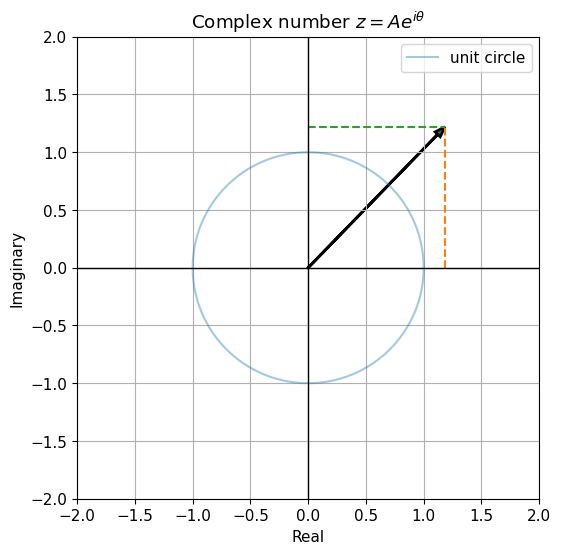

z = 1.184 + 1.220i
|z| = 1.700
angle = 0.800 radians


In [2]:
A = 1.7
theta0 = 0.8
z = A*np.exp(1j*theta0)

fig, ax = plt.subplots(figsize=(6, 6))
angle = np.linspace(0, 2*np.pi, 400)
ax.plot(np.cos(angle), np.sin(angle), alpha=0.4, label="unit circle")
ax.arrow(0, 0, z.real, z.imag, head_width=0.06, length_includes_head=True, linewidth=2)
ax.plot([z.real, z.real], [0, z.imag], "--")
ax.plot([0, z.real], [z.imag, z.imag], "--")
ax.set_aspect("equal", adjustable="box")
ax.axhline(0, color="black", linewidth=1)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_title(r"Complex number $z=Ae^{i\theta}$")
ax.set_xlabel("Real")
ax.set_ylabel("Imaginary")
ax.legend()
plt.show()

print(f"z = {z.real:.3f} + {z.imag:.3f}i")
print(f"|z| = {abs(z):.3f}")
print(f"angle = {np.angle(z):.3f} radians")

## Euler's theorem on the circle

As $\theta$ changes, $e^{i\theta}$ moves around the unit circle. Its real part is $\cos\theta$ and its imaginary part is $\sin\theta$.

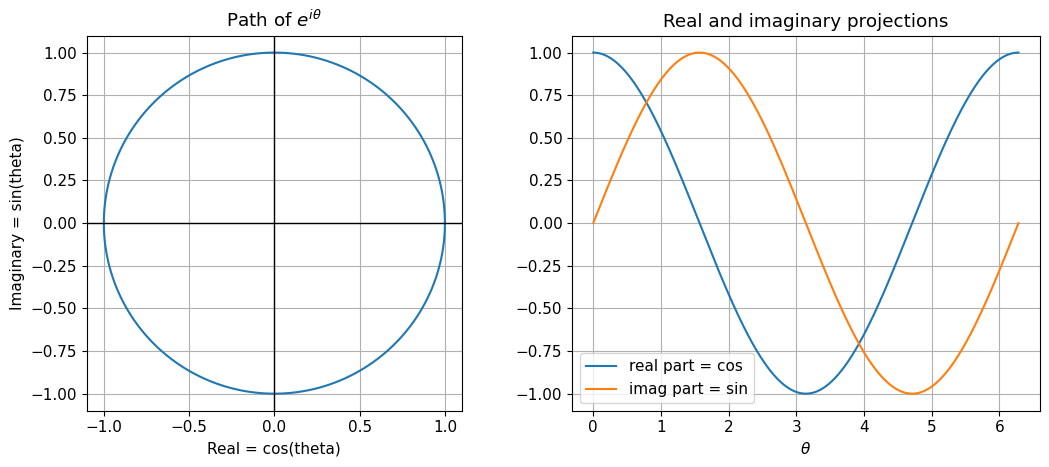

In [3]:
theta = np.linspace(0, 2*np.pi, 400)
z = np.exp(1j*theta)

fig, axs = plt.subplots(1, 2, figsize=(11, 4.8))
axs[0].plot(z.real, z.imag)
axs[0].set_aspect("equal", adjustable="box")
axs[0].set_title(r"Path of $e^{i\theta}$")
axs[0].set_xlabel("Real = cos(theta)")
axs[0].set_ylabel("Imaginary = sin(theta)")
axs[0].axhline(0, color="black", linewidth=1)
axs[0].axvline(0, color="black", linewidth=1)
axs[1].plot(theta, z.real, label="real part = cos")
axs[1].plot(theta, z.imag, label="imag part = sin")
axs[1].set_title("Real and imaginary projections")
axs[1].set_xlabel(r"$\theta$")
axs[1].legend()
plt.tight_layout()
plt.show()

## Complex waves: anti-clockwise and clockwise rotation

$$e^{i\omega t} = \cos(\omega t)+i\sin(\omega t),$$

$$e^{-i\omega t} = \cos(\omega t)-i\sin(\omega t).$$

The real parts match; the imaginary parts have opposite signs.

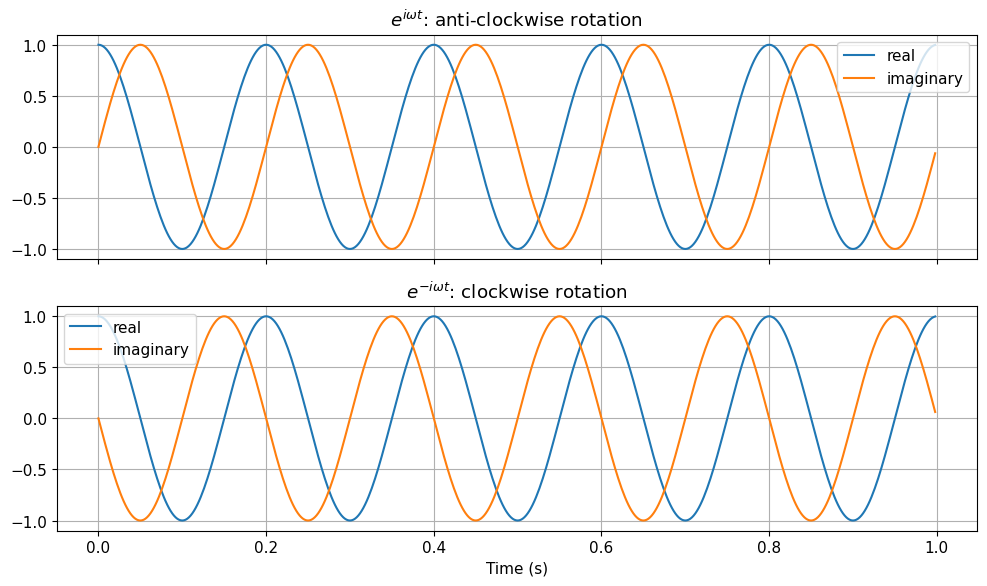

In [4]:
R = 500
T = 1.0
t = np.arange(int(R*T))/R
f = 5
omega = 2*np.pi*f
z_pos = np.exp(1j*omega*t)
z_neg = np.exp(-1j*omega*t)

fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axs[0].plot(t, z_pos.real, label="real")
axs[0].plot(t, z_pos.imag, label="imaginary")
axs[0].set_title(r"$e^{i\omega t}$: anti-clockwise rotation")
axs[0].legend()
axs[1].plot(t, z_neg.real, label="real")
axs[1].plot(t, z_neg.imag, label="imaginary")
axs[1].set_title(r"$e^{-i\omega t}$: clockwise rotation")
axs[1].set_xlabel("Time (s)")
axs[1].legend()
plt.tight_layout()
plt.show()

## A real cosine is two counter-rotating arrows

Adding the two complex waves cancels the imaginary parts:

$$e^{i\omega t} + e^{-i\omega t} = 2\cos(\omega t).$$

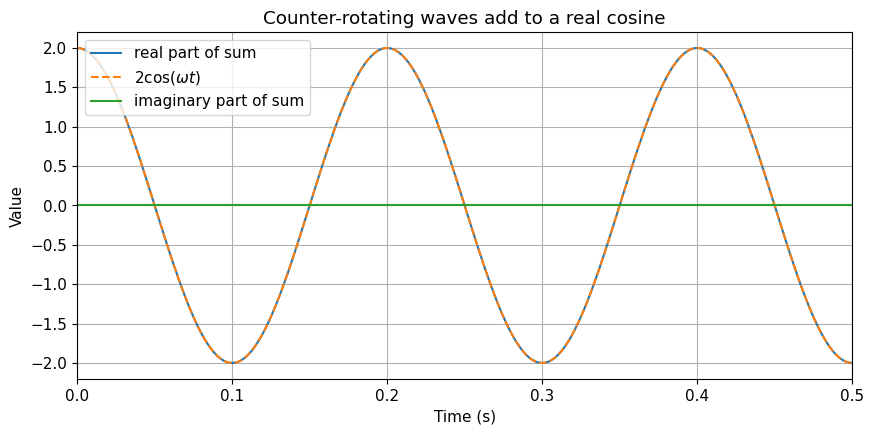

Maximum imaginary part after adding: 0.0


In [5]:
sum_waves = z_pos + z_neg

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(t, sum_waves.real, label="real part of sum")
ax.plot(t, 2*np.cos(omega*t), "--", label=r"$2\cos(\omega t)$")
ax.plot(t, sum_waves.imag, label="imaginary part of sum")
ax.set_xlim(0, 0.5)
ax.set_title("Counter-rotating waves add to a real cosine")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Value")
ax.legend()
plt.show()

print("Maximum imaginary part after adding:", np.max(np.abs(sum_waves.imag)))

## Complex coefficients set amplitude and phase

The real sinusoid

$$C\cos(\omega t)+D\sin(\omega t)$$

can be written as

$$\hat A_+ e^{i\omega t}+\hat A_- e^{-i\omega t},$$

where

$$\hat A_+ = \frac{C-iD}{2}, \qquad \hat A_- = \frac{C+iD}{2}.$$

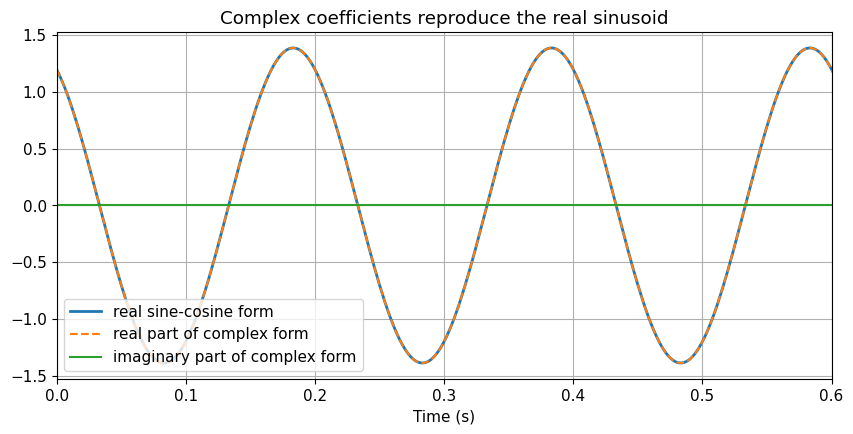

A_plus: (0.6+0.35j)
A_minus: (0.6-0.35j)
|A_plus| + |A_minus| = 1.3892443989449803
sqrt(C^2+D^2)       = 1.3892443989449803
Max reconstruction error: 2.220446049250313e-16


In [6]:
C, D = 1.2, -0.7
A_plus = (C - 1j*D)/2
A_minus = (C + 1j*D)/2

real_form = C*np.cos(omega*t) + D*np.sin(omega*t)
complex_form = A_plus*np.exp(1j*omega*t) + A_minus*np.exp(-1j*omega*t)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(t, real_form, linewidth=2, label="real sine-cosine form")
ax.plot(t, complex_form.real, "--", label="real part of complex form")
ax.plot(t, complex_form.imag, label="imaginary part of complex form")
ax.set_xlim(0, 0.6)
ax.set_title("Complex coefficients reproduce the real sinusoid")
ax.set_xlabel("Time (s)")
ax.legend()
plt.show()

print("A_plus:", A_plus)
print("A_minus:", A_minus)
print("|A_plus| + |A_minus| =", abs(A_plus)+abs(A_minus))
print("sqrt(C^2+D^2)       =", np.hypot(C, D))
print("Max reconstruction error:", np.max(np.abs(real_form - complex_form.real)))

## Checkpoint

1. Why does a real signal need both positive and negative complex frequencies?
2. What happens to the complex coefficients if `D` changes sign?
3. Change `C` and `D`. Verify that $|\hat A_+|+|\hat A_-|=\sqrt{C^2+D^2}$.